In [1]:
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.transforms as transforms
import subprocess
import astropy.units as u
from synphot import SpectralElement, Empirical1D, SourceSpectrum, Observation

from model_W0116_spec import model_W0116_spec
from gasPolModel import PolModel

import os
gd_folder = os.getcwd()+"/../Calculations/Gas_and_dust/"

import sys 
sys.path.append(gd_folder)
from polWaveDust import PolWaveDust
from polWaveGas import PolWaveGas

sys.path.append("../plots/utility_functions/")
from objectProperties import ObjectProperties
from readExtrapolatedSpectra import ReadExtrapolatedSpectra

sys.path.append("../Filter_Curves/")
from readBands import ReadBands

In [2]:
#Load the properties of the BHDs
wid = "W0116-0505"
op = ObjectProperties([wid])

In [3]:
#Load the bands.
bands = ReadBands()
for bname in bands.bandnames:
    print(bname, bands.bp[bname].barlam(), bands.bp[bname].fwhm(), bands.bp[bname].rectwidth())

R_SPECIAL 6501.229535920617 Angstrom 1159.881393925198 Angstrom 1624.9974574790472 Angstrom
I_BESS 7925.773360798338 Angstrom 1080.5202412457434 Angstrom 1433.1539789444323 Angstrom
v_HIGH 5531.691038305597 Angstrom 850.6231300284223 Angstrom 1195.0838113345558 Angstrom


In [4]:
#Load the spectra for each BHD, extended using the best-fit SED, although here we will not care about the extension.
specs = ReadExtrapolatedSpectra()

Wavelength range for object W0019-1046 limited because of sky template
Spec-range: 3001.5 Angstrom - 5423.93 Angstrom
Sky-range: 3199.4 Angstrom - 6724.06 Angstrom
Wavelength range for object W0204-0506 limited because of sky template
Spec-range: 3786.2 Angstrom - 6672.70 Angstrom
Sky-range: 3789.3 Angstrom - 6682.76 Angstrom
Warning, 2 of 3161 bins contained negative fluxes; they have been set to zero.
Wavelength range for object W0831+0140 limited because of sky template
Spec-range: 3786.2 Angstrom - 6672.45 Angstrom
Sky-range: 3789.3 Angstrom - 6682.76 Angstrom
Warning, 2 of 3161 bins contained negative fluxes; they have been set to zero.


## Spectrum, spectrum model and general pol model object

In [5]:
#Load the spectrum. 
spec, spec_model = model_W0116_spec(specs)

In [6]:
full_spec = SourceSpectrum(Empirical1D, points=spec.lam_obs, lookup_table=spec.flam, keep_neg=True)

In [7]:
pol_model = PolModel(spec, spec_model, bands, op)

In [8]:
#Dictionaries to save the results.
xopt_all  = dict()
mod_p_all = dict() 
mod_chi_all = dict()

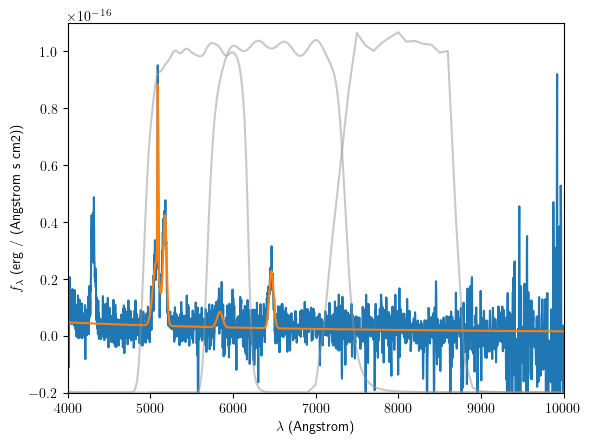

In [9]:
#Plot the spectrum, the best-fit model, and the filter curves.
pol_model.spec_plot()

(-5e-17, 5e-17)

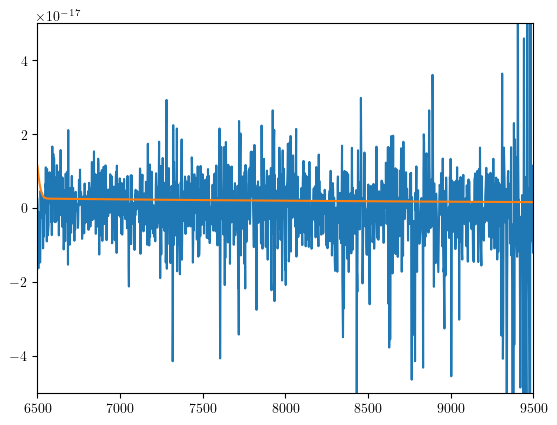

In [10]:
plt.plot(spec.lam_obs, spec.flam-spec_model.flam_model(spec.lam_rest))
plt.plot(spec.lam_obs, spec_model.flam_model(spec.lam_rest))
plt.xlim([6500, 9500])
plt.ylim([-5e-17, 5e-17])

In [11]:
#General plotting function
def pol_plot(mod_p, spec, pol_model, fmt="ko", show_legend=True):

    # data = np.loadtxt("pol_measurements.dat", usecols=[1,2])
    # p_measured = data[:,0]
    # p_unc = data[:,1]
    p_measured =pol_model.p_measured
    p_unc = pol_model.p_unc

    wave = np.array([5500., 6500., 8000.]) / spec.zspec

    fig, ax = plt.subplots(1)

    #ax.errorbar(wave, p_measured, yerr=p_unc, fmt='ko', label='Measurements')
    ax.errorbar(wave, p_measured, yerr=p_unc, fmt=fmt, label='Measurements')
    for scat_type in mod_p.keys():
        if scat_type[-3:]=="LMC":
            fmt = '^'
        elif scat_type[-3:]=="SMC":
            fmt = 's'
        elif scat_type[-2:]=="MW":
            fmt = 'P'
        else:
            fmt='p'

        ax.plot(wave, mod_p[scat_type], fmt, label=scat_type)

    if show_legend:
        ax.legend(ncol=3)
    ax.set_xlabel('Wavelength (Angstroms)')
    ax.set_ylabel('Polarization fraction')
    plt.show()

## Pure Gas Polarization

#### Same inclination for Continuum and Lines

In [12]:
#Define the scattering object
class Gas_Gas(object):

    def __init__(self):

        #Set the number of parameters for the continuum (a) and the lines (b). The order in x is always: delta_chi, a model parameters, b model parameters (if any).
        self.npar_a = 2

        #Load the simple gas model. 
        self.gas_obj = PolWaveGas()

        return

    #In this model, the continuum and emission line polarization fraction is forced to be the same. 
    def pfrac(self, x):
        a_pars = x[1:self.npar_a+1]
        theta = a_pars[0]
        psi = a_pars[1]
        return self.gas_obj.p(([theta],[psi])).flatten()[0]
    
    #Continuum polarization fraction    
    def pfrac_A(self, x):
        return self.pfrac(x)

    #Line polarization fraction    
    def pfrac_B(self, x):
        return self.pfrac(x)

In [13]:
scat_obj = Gas_Gas()

##### Force the same polarization angle. 

In [14]:
x0 = np.array([0., 80., 50.])
min_vals = np.array([0., 0., 0.])
max_vals = np.array([0., 90., 90.])
pol_model.fit_pol(scat_obj, x0, min_vals, max_vals, method='trust-constr')
#pol_model.fit_pol(scat_obj, x0, min_vals, max_vals, method='BFGS')

mname = "GG0"
xopt_all[mname]  = pol_model.xopt
mod_p_all[mname] = pol_model.mod_p
mod_chi_all[mname] = pol_model.mod_chi

`xtol` termination condition is satisfied.
[-3.19823754e-23  7.47127348e+01  7.47352847e+01]
55.82422313308916


In [15]:
x0 = np.array([0., 80., 50.])
min_vals = np.array([0., 0., 0.])
max_vals = np.array([0., 90., 90.])
pol_model.fit_pol_MCMC(scat_obj, x0, min_vals, max_vals)

100%|██████████| 5000/5000 [02:13<00:00, 37.42it/s]


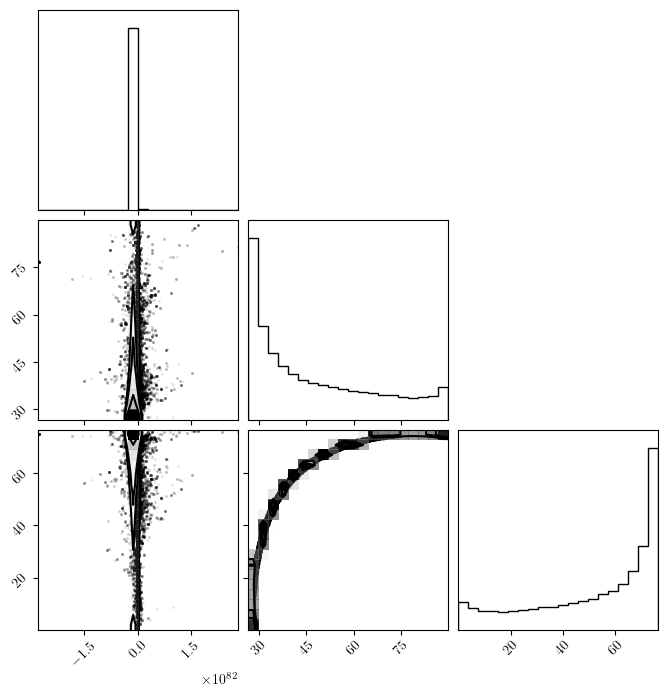

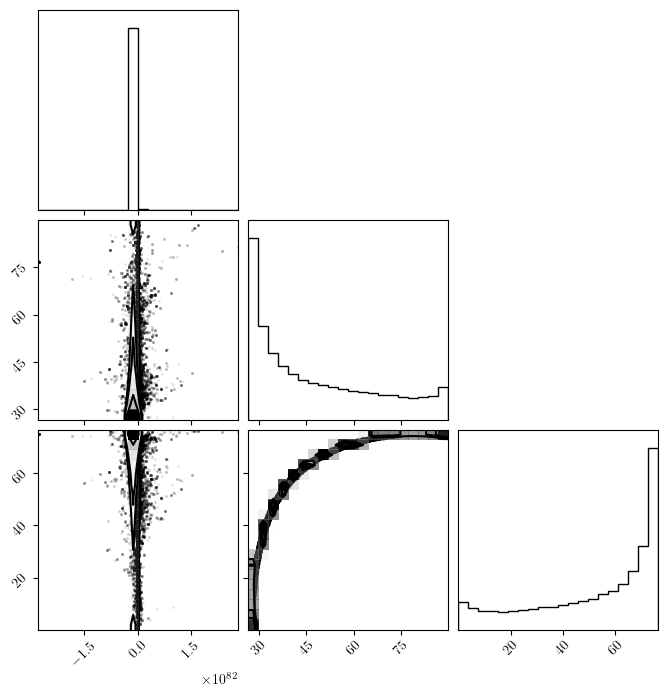

In [ ]:
import corner
flat_samples_GG0 = pol_model.sampler.get_chain(flat=True)
corner.corner(flat_samples_GG0)

[0.12001494]


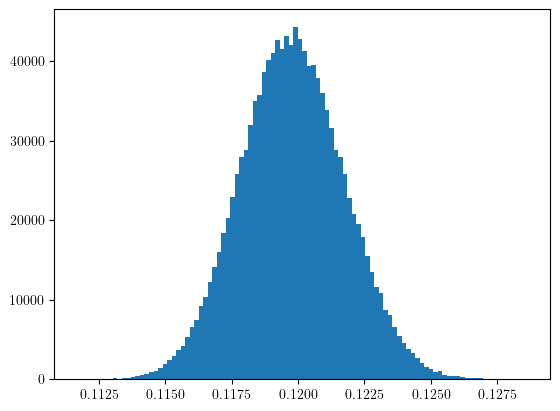

In [ ]:
gas_obj = PolWaveGas()
flat_samples_GG0 = pol_model.sampler.get_chain(flat=True)
print(gas_obj.p(([pol_model.xopt.x[1]], pol_model.xopt.x[2])))
p_values = gas_obj.p((flat_samples_GG0[:,1], flat_samples_GG0[:,2]))
hist = plt.hist(p_values, bins=100)

##### Allow for different polarization angles.

In [18]:
x0 = np.array([0., 80., 50.])
min_vals = np.array([0., 0., 0.])
max_vals = np.array([90., 90., 90.])
pol_model.fit_pol(scat_obj, x0, min_vals, max_vals, method='trust-constr')
#pol_model.fit_pol(scat_obj, x0, min_vals, max_vals, method='BFGS')

mname = "GG1"
xopt_all[mname]  = pol_model.xopt
mod_p_all[mname] = pol_model.mod_p
mod_chi_all[mname] = pol_model.mod_chi

`xtol` termination condition is satisfied.
[38.8611405  67.65513902 71.2451484 ]
26.555689244264936


In [19]:
x0 = np.array([40., 60., 70.])
min_vals = np.array([0., 0., 0.])
max_vals = np.array([90., 90., 90.])
pol_model.fit_pol(scat_obj, x0, min_vals, max_vals, method='trust-constr')
#pol_model.fit_pol(scat_obj, x0, min_vals, max_vals, method='BFGS')

mname = "GG1"
xopt_all[mname]  = pol_model.xopt
mod_p_all[mname] = pol_model.mod_p
mod_chi_all[mname] = pol_model.mod_chi

`xtol` termination condition is satisfied.
[38.86114085 60.36581416 68.95685151]
26.55568924426556


In [20]:
x0 = np.array([40., 60., 70.])
min_vals = np.array([0., 0., 0.])
max_vals = np.array([90., 90., 90.])
pol_model.fit_pol_MCMC(scat_obj, x0, min_vals, max_vals)

100%|██████████| 5000/5000 [02:22<00:00, 35.05it/s]


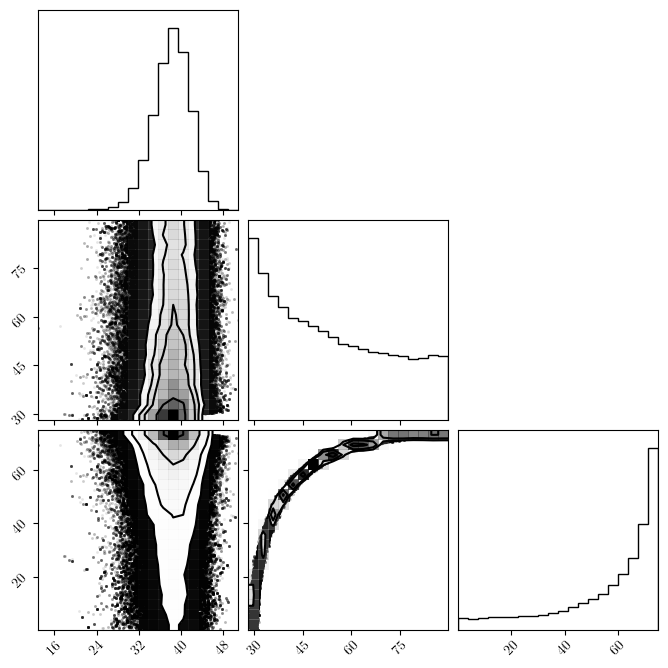

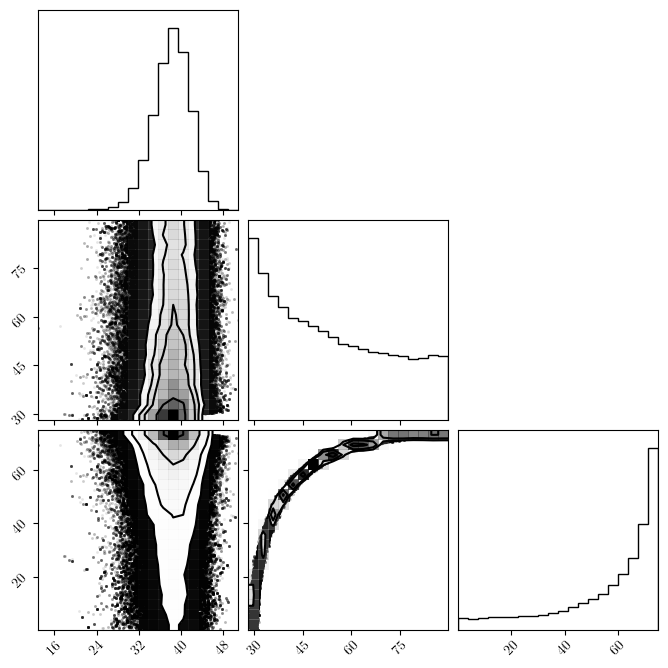

In [21]:
import corner
flat_samples_GG1 = pol_model.sampler.get_chain(flat=True)
corner.corner(flat_samples_GG1)

[0.1405406]


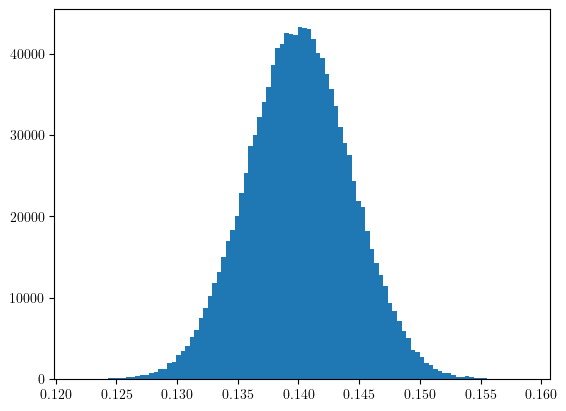

In [24]:
gas_obj = PolWaveGas()
print(gas_obj.p(([pol_model.xopt.x[1]], pol_model.xopt.x[2])))
p_values = gas_obj.p((flat_samples_GG1[:,1], flat_samples_GG1[:,2]))
hist = plt.hist(p_values, bins=100)

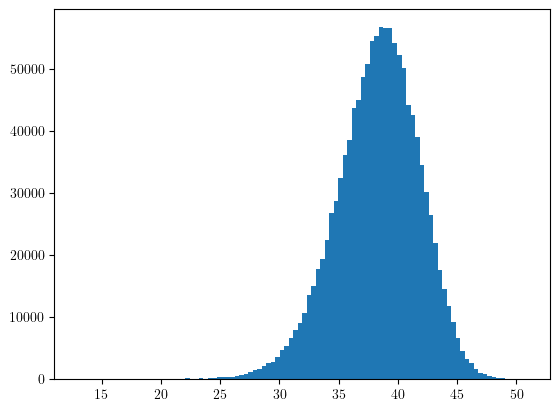

In [25]:
hist2 = plt.hist(flat_samples_GG1[:,0], bins=100)

#### Allow for independent torus opening angles for lines and continuum.

I *believe* that a scatterer very near the accretion disk should be able to be modeled by allowing for different opening angles, which in that model would just simply become for the lines the size of the BLR ring shining into a small scatterer, and for the continuum it would become the covering angle by the scatterer.

In [29]:
#Define the scattering object
class Gas_Gas(object):

    def __init__(self):

        #Set the number of parameters for the continuum (a) and the lines (b). The order in x is always: delta_chi, a model parameters, b model parameters (if any).
        self.npar_a = 2
        self.npar_b = 1

        #Load the simple gas model. 
        self.gas_obj = PolWaveGas()

        return

    #In this model, the continuum and emission line polarization fraction is forced to be the same. 
    def pfrac_A(self, x):
        a_pars = x[1:self.npar_a+1]
        theta = a_pars[0]
        psi_A = a_pars[1]
        return self.gas_obj.p(([theta],[psi_A])).flatten()[0] #* np.ones(len(lam))
    
    #Emission line polarization.
    def pfrac_B(self, x):
        a_pars = x[1:self.npar_a+1]
        theta = a_pars[0]
        b_pars = x[self.npar_a+1:]
        psi_B = b_pars[0]
        return self.gas_obj.p(([theta],[psi_B])).flatten()[0] #* np.ones(len(lam))
    

In [31]:
scat_obj = Gas_Gas()

In [32]:
x0 = np.array([0., 80., 50., 50.])
min_vals = np.array([0., 0., 0., 0.])
max_vals = np.array([90., 90., 90., 90.])
pol_model.fit_pol(scat_obj, x0, min_vals, max_vals, method='trust-constr')
#pol_model.fit_pol(scat_obj, x0, min_vals, max_vals, method='BFGS')

mname = "GG2"
xopt_all[mname]  = pol_model.xopt
mod_p_all[mname] = pol_model.mod_p
mod_chi_all[mname] = pol_model.mod_chi

`xtol` termination condition is satisfied.
[60.47713984 61.75383022 69.10994203 38.83980426]
2.0917993211739954e-11


In [33]:
pol_model.mod_chi.to(u.deg)

<Quantity [4.31984369e+01, 3.40638396e+01, 2.91598222e-03] deg>

In [34]:
pol_model.fit_pol_MCMC(scat_obj, x0, min_vals, max_vals)

100%|██████████| 5000/5000 [02:13<00:00, 37.53it/s]


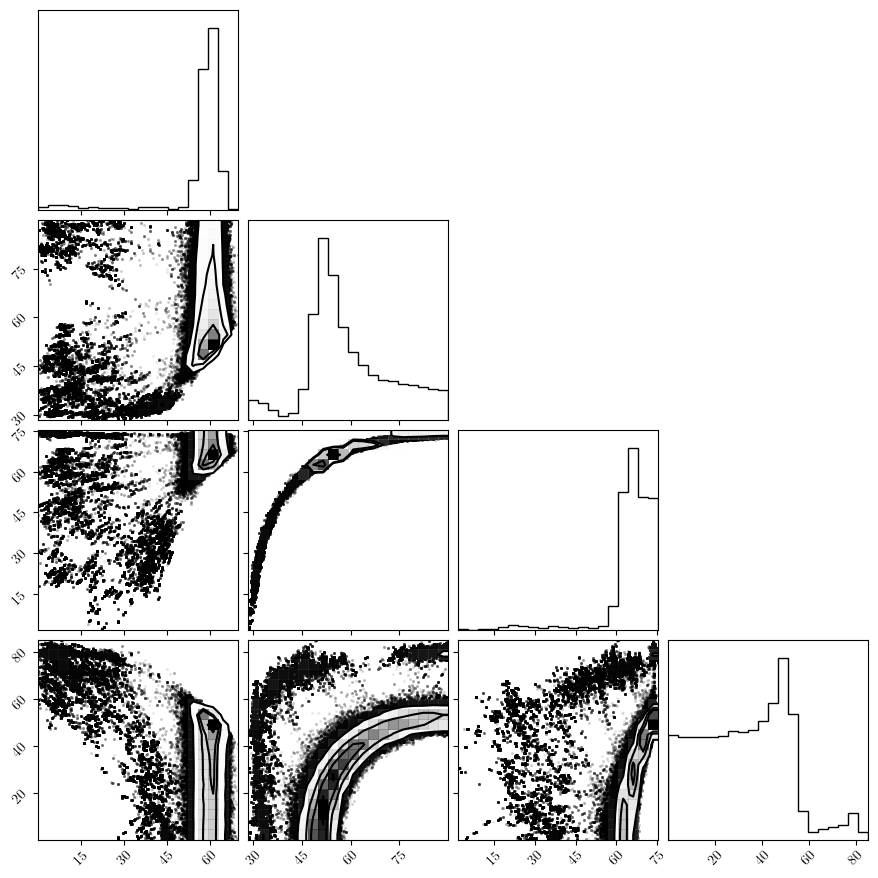

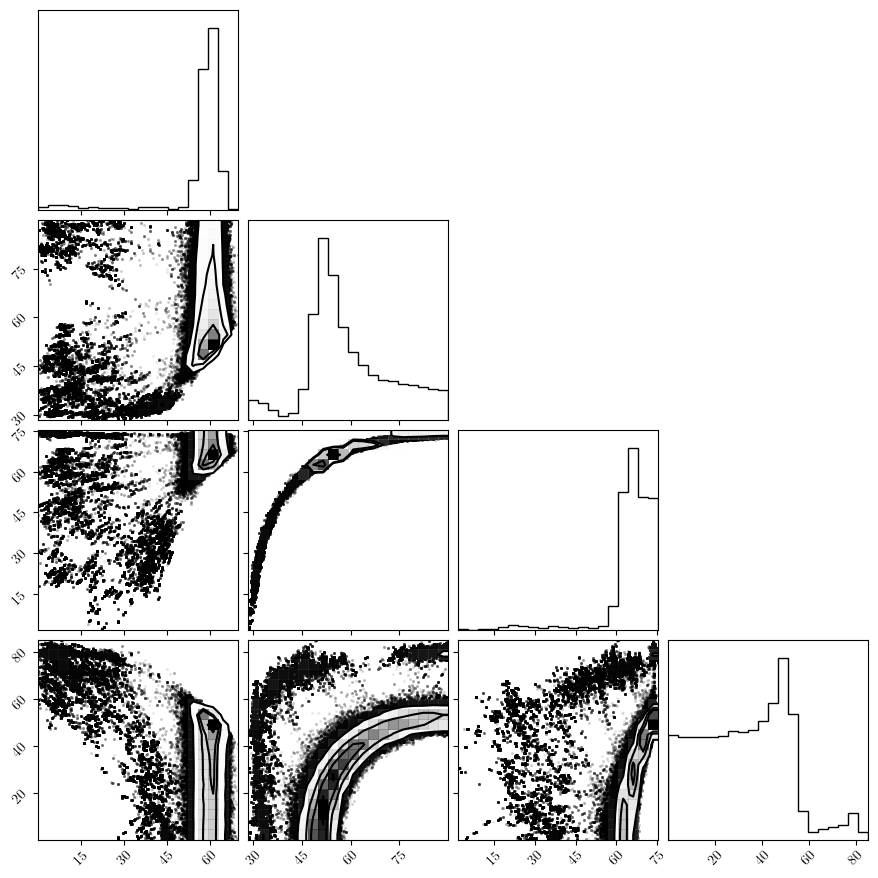

In [35]:
import corner
flat_samples_GG2 = pol_model.sampler.get_chain(flat=True)
corner.corner(flat_samples_GG2)

[0.14361768]


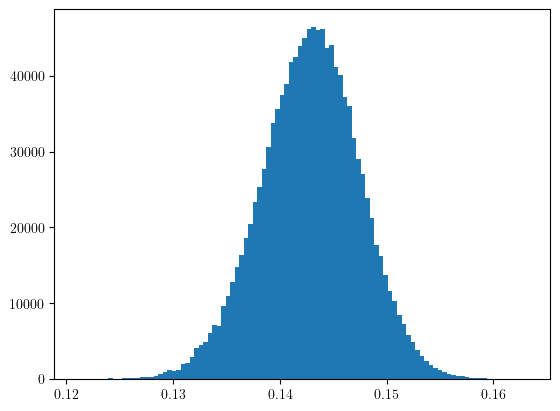

In [36]:
gas_obj = PolWaveGas()
print(gas_obj.p(([pol_model.xopt.x[1]], pol_model.xopt.x[2])))
p_values = gas_obj.p((flat_samples_GG2[:,1], flat_samples_GG2[:,2]))
hist = plt.hist(p_values, bins=100)

[0.42749795]


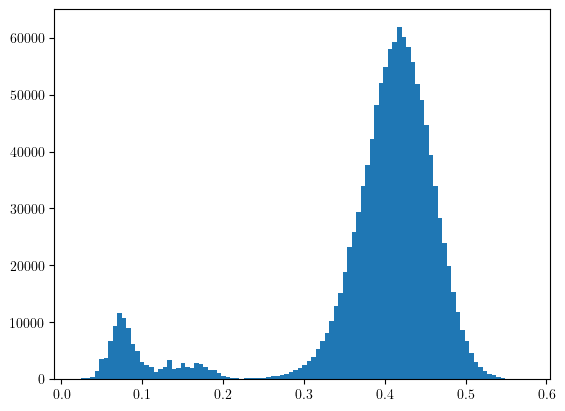

In [37]:
gas_obj = PolWaveGas()
print(gas_obj.p(([pol_model.xopt.x[1]], pol_model.xopt.x[3])))
p_values = gas_obj.p((flat_samples_GG2[:,1], flat_samples_GG2[:,3]))
hist = plt.hist(p_values, bins=100)

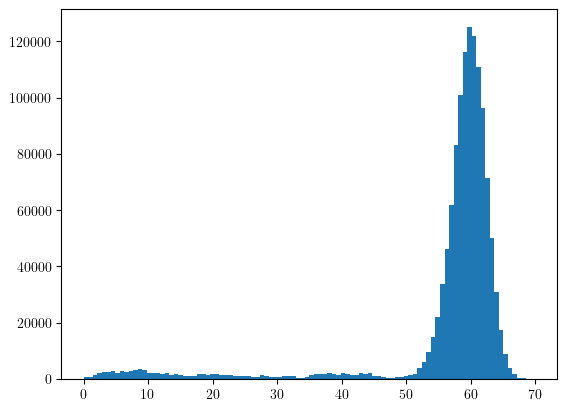

In [38]:
hist2 = plt.hist(flat_samples_GG2[:,0], bins=100)

Now, force the polarization angle to be the same, as suggested by the edge on view of Zakamska & Alexandroff (2023).

In [39]:
x0 = np.array([0., 80., 30., 70.])
min_vals = np.array([0., 0., 0., 0.])
max_vals = np.array([0., 90., 90., 90.])
pol_model.fit_pol(scat_obj, x0, min_vals, max_vals, method='trust-constr')
#pol_model.fit_pol(scat_obj, x0, min_vals, max_vals, method='BFGS')

mname = "GG3"
xopt_all[mname]  = pol_model.xopt
mod_p_all[mname] = pol_model.mod_p
mod_chi_all[mname] = pol_model.mod_chi

`xtol` termination condition is satisfied.
[-1.43490230e-25  5.66491438e+01  6.76465362e+01  7.85477017e+01]
32.52106668158482


In [41]:
scat_obj.pfrac_A(pol_model.xopt.x), scat_obj.pfrac_B(pol_model.xopt.x)

(0.1382139492260068, 0.06245634333132186)

Now allow for the polarization angle to change, but force the inclination angle to be 90 degrees. 

In [42]:
x0 = np.array([0., 90., 30., 70.])
min_vals = np.array([0., 90., 0., 0.])
max_vals = np.array([90., 90., 90., 90.])
pol_model.fit_pol(scat_obj, x0, min_vals, max_vals, method='trust-constr')
#pol_model.fit_pol(scat_obj, x0, min_vals, max_vals, method='BFGS')

mname = "GG4"
xopt_all[mname]  = pol_model.xopt
mod_p_all[mname] = pol_model.mod_p

`gtol` termination condition is satisfied.
[60.47714936 90.         73.4722463  51.8990642 ]
2.5413285422380494e-12


In [44]:
scat_obj.pfrac_A(pol_model.xopt.x), scat_obj.pfrac_B(pol_model.xopt.x)

(0.14361768021035215, 0.4274981095516322)

In [45]:
pol_model.mod_p

<Quantity [0.0962    , 0.1111    , 0.14360001]>

In [46]:
pol_model.mod_chi.to(u.deg)

<Quantity [4.31984527e+01, 3.40638544e+01, 2.91598266e-03] deg>